
这一章的核心思想是：**群体的智慧通常优于个体的智慧**。如果我们将一组预测器（如分类器或回归器）的预测结果汇集起来，通常会得到比最好的单个预测器更好的结果。这种一组预测器的组合，我们就称之为**集成（Ensemble）**。

---

### 第七章核心内容概览

这一章将学习如何构建和训练“模型团队”，主要分为以下四大板块：

#### 1. 投票分类器 (Voting Classifiers)

* **硬投票 (Hard Voting)**：少数服从多数，直接统计各个模型预测结果的胜出次数。
* **软投票 (Soft Voting)**：如果所有分类器都能估算概率（即有 `predict_proba()` 方法），则取平均概率，这通常能获得更高的准确度。

#### 2. Bagging 和 Pasting

* 这是**随机森林**的基石。
* 通过在训练集的不同随机子集上训练相同的算法来增加多样性。
* **Bagging (放回采样)** 与 **Pasting (不放回采样)** 的对比。
* **随机森林 (Random Forests)**：专门针对决策树优化的 Bagging 集成。

#### 3. 提升法 (Boosting)

* **AdaBoost**：不断关注被前一个预测器“带偏”的训练实例，按顺序进行修正。
* **梯度提升 (Gradient Boosting, GBRT)**：通过拟合前一个预测器的残差来修正模型。
* **XGBoost**：工业界非常流行的梯度提升高效实现。

#### 4. 堆叠法 (Stacking)

* 不再简单地用投票来聚合，而是训练一个专门的模型（元学习器）来学习如何组合各个预测器的结果。

---

# 投票分类器

投票分类器（Voting Classifier），其核心逻辑是通过组合多个独立的模型来提升整体的预测性能。

### 1. 核心思想：群体的智慧

* **集体预测**：即使每个分类器都是“弱学习器”（预测准确率仅略高于随机猜测），只要集成的分类器数量足够多且彼此独立，集成模型就有可能成为一个“强学习器”，获得极高的准确率。
* **大数定律 (Law of Large Numbers)**：随着投掷次数（或分类器数量）的增加，正面的比例会越来越接近其概率值。在集成学习中，这意味着当参与投票的模型越多，群体犯错的概率就会越低。

---

### 2. 两种主要的投票方式

在 Scikit-Learn 中，`VotingClassifier` 提供了两种模式：

* **硬投票 (Hard Voting)**：
* **原则**：少数服从多数。
* **逻辑**：每个分类器对样本进行预测，统计每个类别的票数，得票最多的类别即为最终预测结果。


* **软投票 (Soft Voting)**：
* **原则**：权重平均。
* **逻辑**：如果所有分类器都能估算类别的概率（即具备 `predict_proba()` 方法），集成模型会对所有分类器的概率分布取平均值，并将概率最高的类别作为预测结果。
* **优点**：由于它赋予了高置信度预测更大的权重，通常比硬投票的表现更优秀。

---

### 3. 实现步骤与注意事项

* **模型独立性**：为了让集成发挥最大威力，应该使用算法完全不同的分类器（例如：逻辑回归、SVM、随机森林等）。不同的算法会犯不同类型的错误，从而在投票时互相抵消。

---

In [1]:
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=500, noise=0.3, random_state=42)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

log_clf = LogisticRegression()
rnd_clf = RandomForestClassifier()
svm_clf = SVC()
voting_clf = VotingClassifier(
    estimators=[('lr', log_clf),('rf', rnd_clf),('svc', svm_clf)],
    voting='hard'
)
voting_clf.fit(X_train,y_train)

,estimators,"[('lr', ...), ('rf', ...), ...]"
,voting,'hard'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True


看准确率：

In [2]:
from sklearn.metrics import accuracy_score
for clf in (log_clf, rnd_clf, svm_clf, voting_clf):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    print(clf.__class__,__name__, accuracy_score(y_test, y_pred))

<class 'sklearn.linear_model._logistic.LogisticRegression'> __main__ 0.85
<class 'sklearn.ensemble._forest.RandomForestClassifier'> __main__ 0.88
<class 'sklearn.svm._classes.SVC'> __main__ 0.87
<class 'sklearn.ensemble._voting.VotingClassifier'> __main__ 0.87


软投票：

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=500, noise=0.3, random_state=42)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

log_clf = LogisticRegression()
rnd_clf = RandomForestClassifier()
svm_clf = SVC(probability=True)
voting_clf = VotingClassifier(
    estimators=[('lr', log_clf),('rf', rnd_clf),('svc', svm_clf)],
    voting='soft'
)
voting_clf.fit(X_train,y_train)

,estimators,"[('lr', ...), ('rf', ...), ...]"
,voting,'soft'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True


In [4]:
from sklearn.metrics import accuracy_score
for clf in (log_clf, rnd_clf, svm_clf, voting_clf):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    print(clf.__class__,__name__, accuracy_score(y_test, y_pred))

<class 'sklearn.linear_model._logistic.LogisticRegression'> __main__ 0.85
<class 'sklearn.ensemble._forest.RandomForestClassifier'> __main__ 0.88
<class 'sklearn.svm._classes.SVC'> __main__ 0.87
<class 'sklearn.ensemble._voting.VotingClassifier'> __main__ 0.88


## bagging和pasting

在集成学习中，如果不想使用多种不同的算法（如刚才的逻辑回归+SVM+随机森林），另一种让模型变强的方法是：**让同一种算法在训练集的不同子集上进行训练**。

这就是 **Bagging** 和 **Pasting** 的核心逻辑。

---

### 1. 核心定义：采样方式的区别

这两者的唯一区别在于**抽取样本的方式**：

* **Bagging (Bootstrap Aggregating)**：
* **方式**：**有放回**采样（取样后又放回，同一个样本可能在一个训练器中出现多次）。
* **特点**：由于是自助法（Bootstrapping），每个子集具有更高的多样性。


* **Pasting**：
* **方式**：**无放回**采样（取出的样本不再放回，同一个样本在同一个训练器中只能出现一次）。
* **特点**：每个训练器拿到的都是完全不同的数据片段。

---

### 2. 预测逻辑：从个体到群体

一旦所有的预测器（通常是决策树）训练完成，集成模型就会通过简单的**统计逻辑**来做出最终决策：

* **分类任务**：通常采用 **众数（Statistical Mode）**，即硬投票。
* **回归任务**：通常采用所有预测结果的 **平均值**。

---

### 3. 为什么 Bagging 比单棵树强？

虽然每个单独的预测器（Base Learner）的偏差（Bias）可能比在完整训练集上训练时更高，但通过集成：

* **降低方差 (Variance)**：由于每个模型看到的“风景”不同，它们犯的错误也不同，平均后的结果会显著降低整体方差。
* **并行化**：这是集成学习的一大优势——每个模型都是独立的，你可以利用多核 CPU 甚至分布式集群同时训练它们。

---

### oob 评估 (Out-of-Bag)

在 Bagging 的有放回采样中，平均约有 **37%** 的样本从未被某个预测器采样到，这些样本被称为 **oob 样本**。

* 这意味着不需要额外的验证集！你可以直接用这些“没见过”的数据来评估模型的性能。
* 在 Scikit-Learn 中设置 `oob_score=True` 即可开启这个功能。


## scikit-learn的bagging和pasting

In [5]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bag_clf = BaggingClassifier(
    DecisionTreeClassifier(),
    n_estimators=500,
    max_samples=100,
    bootstrap=True,
    n_jobs=-1
)
bag_clf.fit(X_train, y_train)
y_pred = bag_clf.predict(X_test)

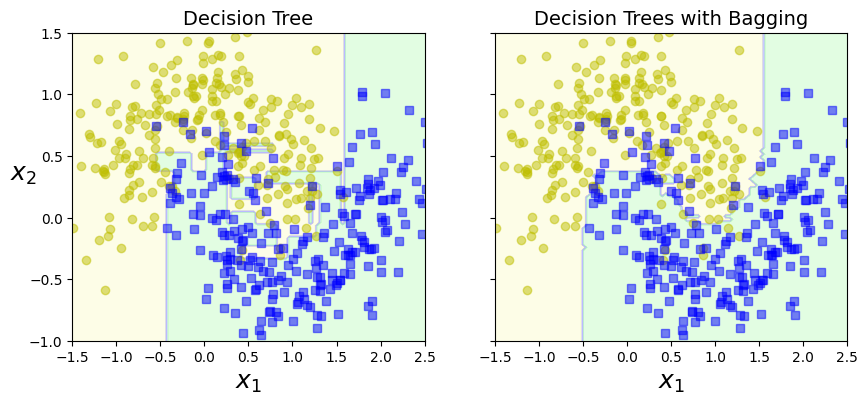

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from matplotlib.colors import ListedColormap

#  训练模型
# 模型 A：单棵决策树（不加约束，容易过拟合）
tree_clf = DecisionTreeClassifier(random_state=42)
tree_clf.fit(X_train, y_train)


#  定义绘图函数来显示区域颜色和边界
def plot_decision_boundary(clf, X, y, axes=[-1.5, 2.5, -1, 1.5], alpha=0.5):
    x1s = np.linspace(axes[0], axes[1], 100)
    x2s = np.linspace(axes[2], axes[3], 100)
    x1, x2 = np.meshgrid(x1s, x2s)
    X_new = np.c_[x1.ravel(), x2.ravel()]
    y_pred = clf.predict(X_new).reshape(x1.shape)

    # 设置背景颜色（区分类别）
    custom_cmap = ListedColormap(['#fafab0','#9898ff','#a0faa0'])
    plt.contourf(x1, x2, y_pred, alpha=0.3, cmap=custom_cmap)

    # 绘制原始数据点
    plt.plot(X[:, 0][y==0], X[:, 1][y==0], "yo", alpha=alpha) # 类别 0
    plt.plot(X[:, 0][y==1], X[:, 1][y==1], "bs", alpha=alpha) # 类别 1

    # 设置坐标轴和标签
    plt.axis(axes)
    plt.xlabel(r"$x_1$", fontsize=18)
    plt.ylabel(r"$x_2$", fontsize=18, rotation=0)

#  绘图对比图 7-5
fig, axes = plt.subplots(ncols=2, figsize=(10, 4), sharey=True)

# 左图：单棵决策树
plt.sca(axes[0])
plot_decision_boundary(tree_clf, X, y)
plt.title("Decision Tree", fontsize=14)

# 右图：500 棵树的 Bagging 集成
plt.sca(axes[1])
plot_decision_boundary(bag_clf, X, y)
plt.title("Decision Trees with Bagging", fontsize=14)
plt.ylabel("") # 隐藏右图的 Y 轴标签，使界面更整洁

plt.show()


可以直观地看到，虽然单棵树能完美拟合训练数据，但其边界极其不规则（过拟合）；而 Bagging 集成的边界则平滑得多，泛化能力更好。

---

### 结果深度解析

1. **左图：单棵决策树 (Decision Tree)**：
* **表现**：边界呈现出大量的“锯齿”和深度切割，甚至为了拟合极个别的噪声点而产生孤立的分类区域。
* **诊断**：这是典型的**高方差（Overfitting）**模型。它在训练集上表现完美，但在测试集上通常会“翻车”。


2. **右图：Bagging 集成 (Decision Trees with Bagging)**：
* **表现**：虽然它也是由 500 棵同样的树组成的，但通过让每棵树只看数据的一个随机子集，最终平均得出的预测边界变得**规则且平滑**得多。
* **诊断**：集成的偏差与单棵树相似（它们捕捉同样的总体趋势），但通过集成，模型的**方差显著降低**，这使得它能更好地适应新数据。

---


## 包外评价

在集成学习中，**包外评价（Out-of-Bag Evaluation，简称 oob 评价）** 是 Bagging 方法特有的一个性能评估手段。它允许在不依赖测试集、也不使用交叉验证的情况下，就能获得模型泛化误差的公正评估。
：

### 1. 核心原理：那“消失”的 37%

* **采样数学特性**：在 Bagging 的“有放回采样”（bootstrap）过程中，对于包含 $m$ 个样本的训练集，由于是随机抽取且每次抽完都放回，平均只有约 **63%** 的样本会被某个特定的预测器抽中。
* **oob 样本的定义**：剩下的 **37%** 样本从未参与该预测器的训练，这些未被抽中的样本就被称为该预测器的**包外（oob）样本**。

### 2. 它是如何运作的？

* **独立验证**：既然每个预测器在训练时都没见过它的 oob 样本，那么这些样本就可以直接作为该预测器的“测试集”。
* **集成评估**：对于整个集成模型，系统会对每个样本计算那些“没见过它”的预测器的平均预测结果。最后，通过比较这些预测值与真实标签，计算出整体的准确率或误差。

### 3. 为什么使用 oob 评价？

* **数据利用率极大化**：不需要为了验证而专门切分出一部分数据（如 `X_val`），可以投入 100% 的数据用于模型训练。
* **效率高**：评估过程伴随训练同时完成，不需要进行耗时的多次交叉验证。
* **泛化估算准确**：Scikit-Learn 官方文档和实践证明，oob 评分通常能非常准确地预测模型在实际测试集上的表现。

---

### 4. 决策边界与 oob 的关系

正如上面所看到的对比图，Bagging 产生的决策边界更加规则且平滑。

* 由于每棵树只看到了部分数据，它们各自会有不同的偏差。
* 通过 oob 评价，我们能确认这种“平均化”的操作是否真的有效地降低了模型对噪声点的敏感度。


In [7]:
bag_clf = BaggingClassifier(
    DecisionTreeClassifier(),
    n_estimators=500,
    bootstrap=True,
    n_jobs=-1,
    random_state=42,
    oob_score=True
)
bag_clf.fit(X_train, y_train)
bag_clf.oob_score_

0.91

测试集上验证：

In [8]:
from sklearn.metrics import accuracy_score
y_pred = bag_clf.predict(X_test)
accuracy_score(y_test, y_pred)

0.88

包外概率：

In [9]:
bag_clf.oob_decision_function_

array([[1.        , 0.        ],
       [0.        , 1.        ],
       [0.03157895, 0.96842105],
       [0.95744681, 0.04255319],
       [0.99386503, 0.00613497],
       [1.        , 0.        ],
       [0.98850575, 0.01149425],
       [0.65517241, 0.34482759],
       [0.56382979, 0.43617021],
       [0.        , 1.        ],
       [0.53051643, 0.46948357],
       [0.86567164, 0.13432836],
       [1.        , 0.        ],
       [0.        , 1.        ],
       [0.49489796, 0.50510204],
       [0.97894737, 0.02105263],
       [1.        , 0.        ],
       [1.        , 0.        ],
       [0.98404255, 0.01595745],
       [0.04444444, 0.95555556],
       [0.        , 1.        ],
       [0.        , 1.        ],
       [0.83615819, 0.16384181],
       [0.99494949, 0.00505051],
       [0.75925926, 0.24074074],
       [0.34659091, 0.65340909],
       [0.32978723, 0.67021277],
       [1.        , 0.        ],
       [0.        , 1.        ],
       [0.        , 1.        ],
       [0.

## random patches和随机子空间

在 Bagging 的基础上，如果我们不仅对**样本**进行随机采样，还对**特征**进行随机采样，就能进一步增加模型的多样性并降低过拟合风险。

这就是 **Random Patches** 和 **随机子空间（Random Subspaces）** 的核心逻辑。

---

### 1. 核心定义：维度上的随机性

这两个概念主要是通过 `BaggingClassifier` 中的两个参数来控制的：`max_features` 和 `bootstrap_features`。

#### **Random Patches (随机补丁法)**

* **做法**：同时对**训练实例**和**特征**进行采样。
* **配置**：`bootstrap=True` 且 `bootstrap_features=True`。
* **形象理解**：就像在整张大表上随机抠出一块块“补丁”给每个预测器去学习。

#### **随机子空间 (Random Subspaces)**

* **做法**：保留**所有训练实例**，但只对**特征**进行采样。
* **配置**：`bootstrap=False` 且 `max_samples=1.0`，但 `bootstrap_features=True` 且 `max_features < 1.0`。
* **形象理解**：每个预测器都能看到所有的数据行，但只能看到数据列的一个随机子集（子空间）。

---

### 2. 为什么需要对特征采样？

1. **处理高维数据**：当处理像图像或复杂的金融特征时，特征数量可能非常巨大。对特征采样可以显著加快训练速度。
2. **增加模型多样性**：如果数据中有一个极强的预测特征，所有决策树可能都会优先选它作为根节点，导致树长得太像。随机丢弃一部分特征，可以强迫某些树去挖掘其他“二线”但有效的特征，从而通过集成获得更全面的视角。
3. **降低方差**：虽然这可能会略微增加模型的偏差，但由此带来的方差下降通常能让整体泛化性能变得更好。

---


---

### 总结对比表

| 方法 | 样本采样 (max_samples) | 特征采样 (max_features) | 适用场景 |
| --- | --- | --- | --- |
| **Bagging** | 是 | 否 | 通用场景，降低过拟合 |
| **Random Subspaces** | 否 | 是 | 高维数据，特征间相关性强 |
| **Random Patches** | 是 | 是 | 极大训练集且高维数据 |


# 随机森林

随机森林（Random Forests）本质上是 **决策树的 Bagging 集成**，但通过引入更多的随机性，使模型在保持强大拟合能力的同时，显著降低了过拟合风险。

---

### 1. 核心逻辑：双重随机化

随机森林在构建每棵决策树时，引入了两个维度的随机性：

* **样本随机化**：使用 Bagging（有放回采样）为每棵树抽取独立的训练集。
* **特征随机化**：这是随机森林的**核心改进**。在决策树分裂节点时，不再从所有特征中寻找最优特征，而是先**随机选择一个特征子集**，再从中寻找最优分割点。

---

### 2. 极端随机树 (Extra-Trees)

如果觉得随机森林还不够“随机”，Scikit-Learn 还提供了一个变体：**极端随机树（Extremely Randomized Trees）**。

* **更随机的分割**：随机森林是在特征子集中寻找最佳阈值，而 Extra-Trees 对每个特征**随机抽取阈值**，然后从中选择表现最好的。
* **权衡**：这种做法显著提高了训练速度，并用更高的偏差换取了更低的方差。

---

### 3. 特征重要性 (Feature Importance)

随机森林的一个强大副产品是能够自动评估每个特征的重要性：

* **原理**：观察平均每个特征在森林中减少了多少不纯度（Gini 或 Entropy）。
* **应用**：通过 `feature_importances_` 属性，你可以快速识别哪些特征对预测结果贡献最大，这在金融风控（如识别欺诈特征）或生物医疗中非常有用。


---

### 总结：为什么选随机森林

* **抗噪能力强**：通过对多棵树的结果取平均，抵消了单棵树对训练集细节（甚至噪声）的敏感性。
* **参数简单**：通常只需要调整 `n_estimators`（树的数量）和 `max_features` 就能获得不错的效果。
* **天然并行**：每棵树的构建互不干扰，完美适配多核处理器。


In [10]:
from sklearn.ensemble import RandomForestClassifier

rnd_clf = RandomForestClassifier(n_estimators=500,max_leaf_nodes=16,n_jobs=-1)
rnd_clf.fit(X_train, y_train)

y_pred_rf = rnd_clf.predict(X_test)

In [11]:
bag_clf = BaggingClassifier(
    DecisionTreeClassifier(splitter='random',max_leaf_nodes=16),
    n_estimators=500,
    max_samples=1.0,
    bootstrap=True,
    n_jobs=-1,
    random_state=42
)

## 特征重要性

In [12]:
from sklearn.datasets import load_iris
iris = load_iris()
rnd_clf = RandomForestClassifier(n_estimators=500,n_jobs=-1)
rnd_clf.fit(iris['data'], iris['target'])
for name,score in zip(iris['feature_names'], rnd_clf.feature_importances_):
    print(name, score)

sepal length (cm) 0.1056180186095177
sepal width (cm) 0.022837395119783936
petal length (cm) 0.43057260676529013
petal width (cm) 0.44097197950540823


## 提升法

**提升法（Boosting）**

与 Bagging 的并行思路不同，提升法的核心逻辑是**循序渐进、迭代修正**。它的目标是将多个弱学习器（Weak Learners）组合成一个强学习器。


## AdaBoost

AdaBoost（Adaptive Boosting，自适应提升）是提升法中最经典的算法之一。它的核心逻辑可以概括为：**“关注错题，迭代进化”**。

### 1. 核心工作机制：调整样本权重

AdaBoost 的训练是一个循序渐进的过程，每个新预测器都会修正其前任的错误：

* **初始阶段**：训练第一个基础预测器（通常是决策树桩），所有训练实例的权重相等。
* **权重更新**：算法会评估第一个预测器的表现。被分类错误的实例，其**权重会增加**；而被正确分类的实例，其权重保持不变或降低。
* **迭代进化**：第二个预测器在更新后的权重上进行训练。由于某些样本权重变大，第二个预测器会“被迫”更加关注这些之前分类错误的难点。
* **最终集成**：重复上述过程，直到达到指定的预测器数量或完美拟合。最后，所有预测器根据其自身的准确率（预测器权重）加权组合，做出最终决定。

---

### 2. 预测器权重与样本权重

这里有两个容易混淆的概念：

* **样本权重 ($\omega$)**：决定了当前预测器在训练时对哪些数据点更“走心”。
* **预测器权重 ($\alpha$)**：决定了在最后的“投票阶段”，这个预测器说话的分量有多大。准确率越高的预测器，$\alpha$ 值越高。

---

### 3. Scikit-Learn 实现与参数

Scikit-Learn 提供了 `AdaBoostClassifier`（分类）和 `AdaBoostRegressor`（回归）。

* **Base Estimator**：AdaBoost 默认使用“决策树桩”（`max_depth=1` 的决策树）作为基础预测器。
* **learning_rate**：学习率。缩减每个预测器的贡献。如果在集成中过拟合，可以尝试降低学习率。
* **SAMME.R**：这是 SAMME 的变体，它依靠预测概率而不是预测结果，通常比基础的 SAMME 表现更好。

---

### 4. 优缺点分析

* **优点**：非常擅长通过简单的弱学习器构建出复杂的非线性边界；偏差较低。
* **缺点**：**无法并行训练**（因为每个模型必须等待前一个模型的错误反馈），在大数据集上速度较慢；对噪声和离群点非常敏感，因为算法会拼命尝试纠正这些异常点的错误。

---


原理：
---

### 1. 样本权重初始化

在算法开始时，每个样本都被赋予相等的权重：


$$w^{(i)} = \frac{1}{m}$$


其中 $m$ 是样本总数。

---

### 2. 计算第 $j$ 个预测器的加权误差率 ($r_j$)

对于每一个基础预测器，我们计算它在带权重的训练集上的错误表现：


$$r_j = \frac{\sum_{i=1, \hat{y}_j^{(i)} \neq y^{(i)}}^m w^{(i)}}{\sum_{i=1}^m w^{(i)}}$$

* **分子**：所有被预测错误的样本权重之和。
* **分母**：所有样本的权重总和（通常归一化为 1）。

---

### 3. 计算预测器的权重 ($\alpha_j$)

预测器表现越好（误差率 $r_j$ 越小），其在最终投票中的话语权就越大：


$$\alpha_j = \eta \log \frac{1 - r_j}{r_j}$$

* $\eta$ 是学习率超参数（默认为 1）。
* **逻辑**：如果误差率为 0.5（随机猜测），则 $\alpha_j = 0$；如果误差率接近 0，则 $\alpha_j$ 趋于正无穷。

---

### 4. 更新样本权重 ($w^{(i)}$)

这是算法“自适应”的核心。模型会调高错题的权重，调低对题的权重：
对于 $i = 1, 2, \dots, m$：


$$w^{(i)} \leftarrow \begin{cases} w^{(i)} & \text{如果 } \hat{y}_j^{(i)} = y^{(i)} \\ w^{(i)} \exp(\alpha_j) & \text{如果 } \hat{y}_j^{(i)} \neq y^{(i)} \end{cases}$$

* 更新后，所有权重会除以 $\sum w^{(i)}$ 进行**归一化**。

---

### 5. 最终预测公式

最后，AdaBoost 计算所有预测器的加权投票结果，并取票数最多的类别：


$$\hat{y}(\mathbf{x}) = \text{argmax}_k \sum_{j=1, \hat{y}_j(\mathbf{x}) = k}^N \alpha_j$$


其中 $N$ 是预测器的数量。

---

### 深度理解提示

* **指数增长**：权重更新公式中使用的是 $\exp(\alpha_j)$。这意味着如果一个预测器非常准（$\alpha_j$ 很大），它认错的那个样本在下一轮会被赋予**极其巨大**的权重，强迫下一个模型去关注它。
* **不可并行**：正因为下一轮的权重 $w^{(i)}$ 依赖于上一轮的预测结果 $\hat{y}_j^{(i)}$，所以 AdaBoost 必须串行计算。


In [13]:
from sklearn.ensemble import AdaBoostClassifier

ada_clf = AdaBoostClassifier(
    DecisionTreeClassifier(max_depth=1),
    n_estimators=200,
    algorithm='SAMME',
    learning_rate=0.5
)
ada_clf.fit(X_train, y_train)

C:\Users\24677\PycharmProjects\Hands-On_Machine_Learning_with_Scikit_Learn&TensorFlow\.venv\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


,estimator,DecisionTreeC...r(max_depth=1)
,n_estimators,200
,learning_rate,0.5
,algorithm,'SAMME'
,random_state,None
,criterion,'gini'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0


C:\Users\24677\PycharmProjects\Hands-On_Machine_Learning_with_Scikit_Learn&TensorFlow\.venv\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
C:\Users\24677\PycharmProjects\Hands-On_Machine_Learning_with_Scikit_Learn&TensorFlow\.venv\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


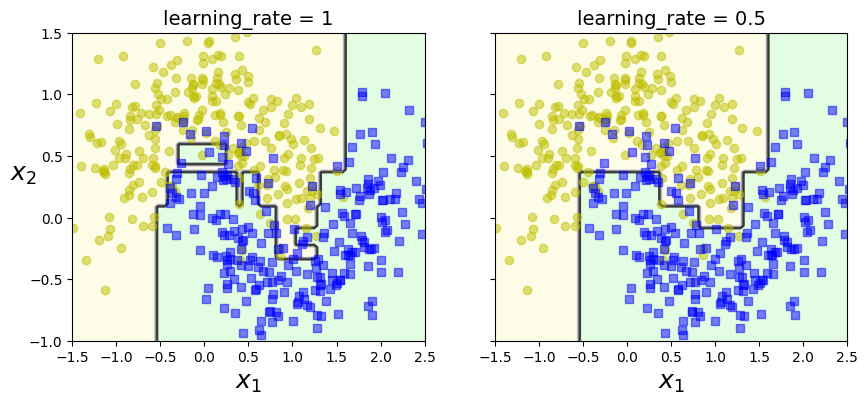

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from matplotlib.colors import ListedColormap

# 1. 准备卫星数据集
X, y = make_moons(n_samples=500, noise=0.30, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# 2. 绘图辅助函数
def plot_decision_boundary(clf, X, y, axes=[-1.5, 2.5, -1, 1.5], alpha=0.5):
    x1s = np.linspace(axes[0], axes[1], 100)
    x2s = np.linspace(axes[2], axes[3], 100)
    x1, x2 = np.meshgrid(x1s, x2s)
    X_new = np.c_[x1.ravel(), x2.ravel()]
    y_pred = clf.predict(X_new).reshape(x1.shape)

    custom_cmap = ListedColormap(['#fafab0','#9898ff','#a0faa0'])
    plt.contourf(x1, x2, y_pred, alpha=0.3, cmap=custom_cmap)
    plt.contour(x1, x2, y_pred, cmap="Greys", alpha=0.8) # 绘制边界线

    plt.plot(X[:, 0][y==0], X[:, 1][y==0], "yo", alpha=alpha)
    plt.plot(X[:, 0][y==1], X[:, 1][y==1], "bs", alpha=alpha)
    plt.axis(axes)
    plt.xlabel(r"$x_1$", fontsize=18)
    plt.ylabel(r"$x_2$", fontsize=18, rotation=0)

# 3. 绘制对比图 (左图学习率 1, 右图学习率 0.5)
fig, axes = plt.subplots(ncols=2, figsize=(10, 4), sharey=True)

# 左图：学习率 = 1 (默认)
plt.sca(axes[0])
m1_ada_clf = AdaBoostClassifier(
    DecisionTreeClassifier(max_depth=1), n_estimators=200,
    algorithm="SAMME", learning_rate=1, random_state=42)
m1_ada_clf.fit(X_train, y_train)
plot_decision_boundary(m1_ada_clf, X, y)
plt.title("learning_rate = 1", fontsize=14)

# 右图：学习率 = 0.5
plt.sca(axes[1])
m05_ada_clf = AdaBoostClassifier(
    DecisionTreeClassifier(max_depth=1), n_estimators=200,
    algorithm="SAMME", learning_rate=0.5, random_state=42)
m05_ada_clf.fit(X_train, y_train)
plot_decision_boundary(m05_ada_clf, X, y)
plt.title("learning_rate = 0.5", fontsize=14)
plt.ylabel("")

plt.show()

## 梯度提升



---

### 梯度提升（Gradient Boosting）核心公式整理


与 AdaBoost 调整样本权重不同，梯度提升是让新的预测器去拟合前一个预测器的**残差（Residual Errors）**。

#### 1. 初始化模型

首先，用一个常数（通常是目标值的均值）来初始化预测器：


$$F_0(\mathbf{x}) = \arg\min_\gamma \sum_{i=1}^m L(y^{(i)}, \gamma)$$

#### 2. 迭代训练（对于 $j = 1$ 到 $N$）

* **A. 计算残差（伪残差）**：计算当前模型预测值与真实值之间的差距。对于平方误差，残差为：

$$r_{i,j} = y^{(i)} - F_{j-1}(\mathbf{x}^{(i)})$$


* **B. 拟合残差**：训练一个新的回归树 $h_j(\mathbf{x})$，使其目标不是预测 $y$，而是预测这个残差 $r_{i,j}$。
* **C. 更新模型（收缩系数）**：将新树的结果乘以学习率 $\eta$ 后加到旧模型上：

$$F_j(\mathbf{x}) = F_{j-1}(\mathbf{x}) + \eta h_j(\mathbf{x})$$



#### 3. 最终预测结果

$$F_N(\mathbf{x}) = \sum_{j=0}^N \eta h_j(\mathbf{x})$$

---

###  核心参数理解

* **`learning_rate`（学习率/收缩率）**：如果设置得很小（如 0.1），需要更多的树（`n_estimators`）来拟合，但通常泛化效果更好。
* **早期停止（Early Stopping）**：为了避免树太多导致过拟合，我们通常会监测验证集误差，一旦误差不再下降就停止增加新树。


 AdaBoost 是通过调整“错题权重”来进步，那么梯度提升就是通过不断**“弥补差距”**来逼近完美的。

---

### 1. 核心运作逻辑：拟合残差

* **第一步：建立基准**。先训练一个非常简单的模型（通常是取所有数据的平均值作为预测结果）。
* **第二步：计算残差**。看第一个模型预测得有多不准，把预测值和真实值之间的“差距”算出来。
* **第三步：修正差距**。训练第二个模型，但这次它的目标**不是预测原始数据**，而是专门去**预测上一个模型留下的那个“差距”**。
* **循环往复**：将新预测出的“差距”加到旧结果上，得到一个更准的结果。然后再计算新的残差，再训练第三个模型去拟合它。

---

### 2. 关键超参数：收缩（Shrinkage）

在梯度提升中，有一个非常重要的参数叫 `learning_rate`（学习率）：

* **慢工出细活**：如果学习率设得很低（比如 0.1），每棵树只能修正一小部分残差。
* **权衡取舍**：虽然这样需要更多的树（`n_estimators`）才能完成拟合，但通常会让模型的泛化能力变强，不容易过拟合。

---

### 3. 早期停止（Early Stopping）：寻找最优解

因为梯度提升非常强大，如果树的数量太多，它最终会把训练集里的噪声也拟合进去（过拟合）。

* **策略**：我们会在训练过程中监测验证集的误差。
* **操作**：一旦发现验证集误差不再下降，甚至开始上升，就立即停止添加新树。这样能找到模型性能最巅峰的那个点。

---

### 4. 优点

* **灵活性**：梯度提升可以自定义各种损失函数（不仅仅是分类错误率），这让它在回归任务中表现极佳。
* **鲁棒性**：它对离群点（Outliers）的敏感度通常比 AdaBoost 低一些。
* **工程进化**：它演化出了 **XGBoost**、**LightGBM** 等工业级利器，是目前金融反欺诈、信贷评分等领域的核心算法。

---


In [15]:

np.random.seed(42)
X = np.random.rand(100, 1) - 0.5
y = 3*X[:, 0]**2 + 0.05 * np.random.randn(100)

In [16]:
from sklearn.tree import DecisionTreeRegressor

tree_reg1 = DecisionTreeRegressor(max_depth=2)
tree_reg1.fit(X,y)

,criterion,'squared_error'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [17]:
y2 = y-tree_reg1.predict(X)
tree_reg2 = DecisionTreeRegressor(max_depth=2)
tree_reg2.fit(X,y2)

,criterion,'squared_error'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [18]:
y3 = y2-tree_reg2.predict(X)
tree_reg3 = DecisionTreeRegressor(max_depth=2)
tree_reg3.fit(X,y3)

,criterion,'squared_error'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [19]:
X_new = np.linspace(-0.5, 0.5, 500).reshape(-1, 1)

y_pred = sum(tree.predict(X) for tree in [tree_reg1, tree_reg2, tree_reg3])

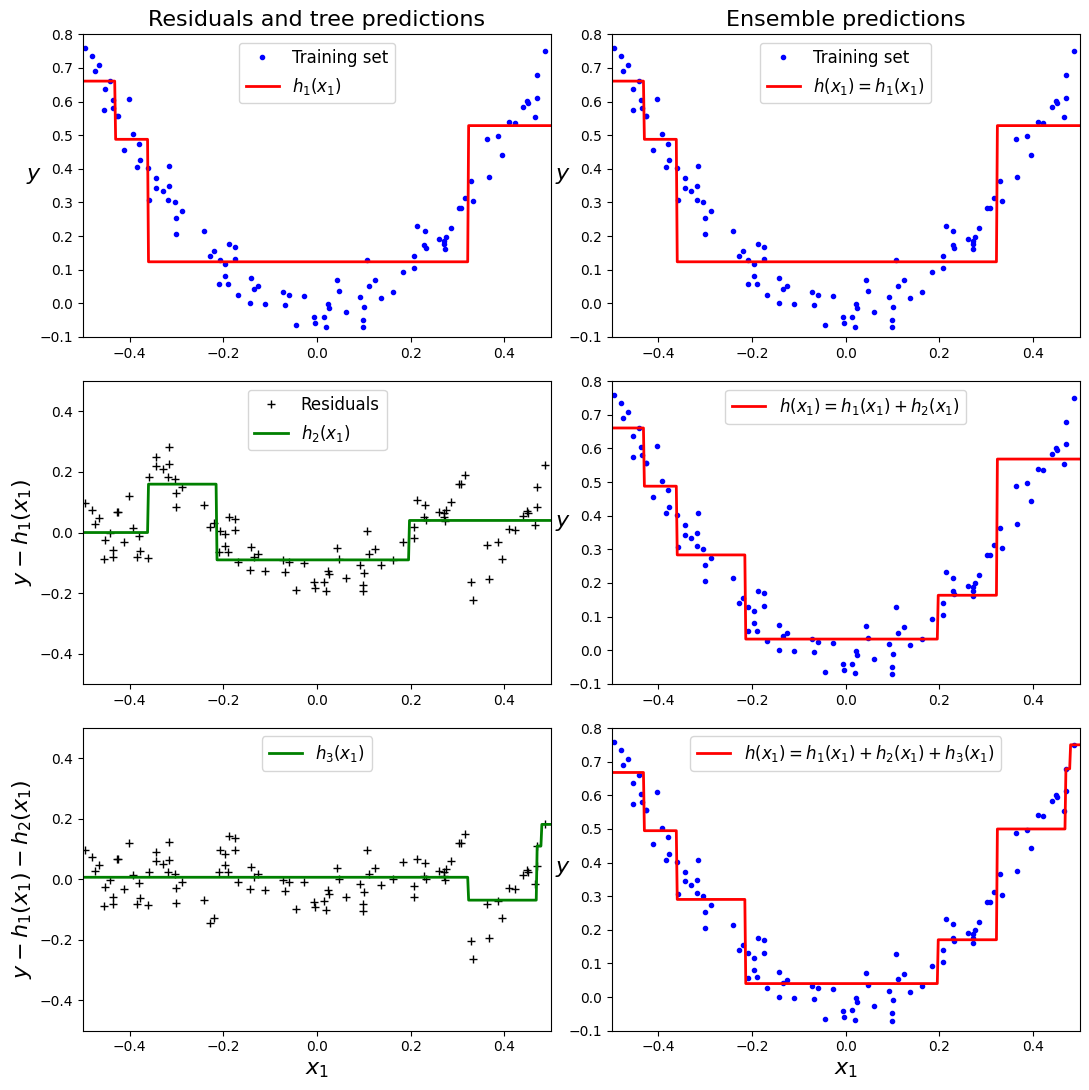

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor


# 2. 绘图辅助函数
def plot_predictions(regressors, X, y, axes, label=None, style="r-", data_style="b.", data_label=None):
    x1 = np.linspace(axes[0], axes[1], 500).reshape(-1, 1)
    y_pred = sum(regressor.predict(x1) for regressor in regressors)
    plt.plot(X[:, 0], y, data_style, label=data_label)
    plt.plot(x1[:, 0], y_pred, style, linewidth=2, label=label)
    if label or data_label:
        plt.legend(loc="upper center", fontsize=12)
    plt.axis(axes)

# 3. 绘制图 7-9
plt.figure(figsize=(11, 11))

# 第一行：第一棵树
plt.subplot(321)
plot_predictions([tree_reg1], X, y, axes=[-0.5, 0.5, -0.1, 0.8], label="$h_1(x_1)$", data_label="Training set")
plt.ylabel("$y$", fontsize=16, rotation=0)
plt.title("Residuals and tree predictions", fontsize=16)

plt.subplot(322)
plot_predictions([tree_reg1], X, y, axes=[-0.5, 0.5, -0.1, 0.8], label="$h(x_1) = h_1(x_1)$", data_label="Training set")
plt.ylabel("$y$", fontsize=16, rotation=0)
plt.title("Ensemble predictions", fontsize=16)

# 第二行：第二棵树
plt.subplot(323)
plot_predictions([tree_reg2], X, y2, axes=[-0.5, 0.5, -0.5, 0.5], label="$h_2(x_1)$", style="g-", data_style="k+", data_label="Residuals")
plt.ylabel("$y - h_1(x_1)$", fontsize=16)

plt.subplot(324)
plot_predictions([tree_reg1, tree_reg2], X, y, axes=[-0.5, 0.5, -0.1, 0.8], label="$h(x_1) = h_1(x_1) + h_2(x_1)$")
plt.ylabel("$y$", fontsize=16, rotation=0)

# 第三行：第三棵树
plt.subplot(325)
plot_predictions([tree_reg3], X, y3, axes=[-0.5, 0.5, -0.5, 0.5], label="$h_3(x_1)$", style="g-", data_style="k+")
plt.ylabel("$y - h_1(x_1) - h_2(x_1)$", fontsize=16)
plt.xlabel("$x_1$", fontsize=16)

plt.subplot(326)
plot_predictions([tree_reg1, tree_reg2, tree_reg3], X, y, axes=[-0.5, 0.5, -0.1, 0.8], label="$h(x_1) = h_1(x_1) + h_2(x_1) + h_3(x_1)$")
plt.ylabel("$y$", fontsize=16, rotation=0)
plt.xlabel("$x_1$", fontsize=16)

plt.tight_layout()
plt.show()

In [21]:
import  numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import GradientBoostingRegressor

X_train,X_val,y_train,y_val = train_test_split(X,y)
gbrt = GradientBoostingRegressor(max_depth=2,n_estimators=120)
gbrt.fit(X_train,y_train)
errors = [mean_squared_error(y_val,y_pred) for y_pred in gbrt.staged_predict(X_val)]
bst_n_estimators = np.argmin(errors)

gbrt_best = GradientBoostingRegressor(max_depth=2,n_estimators=bst_n_estimators)
gbrt_best.fit(X_train,y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,np.int64(52)
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,2
,min_impurity_decrease,0.0
,init,None


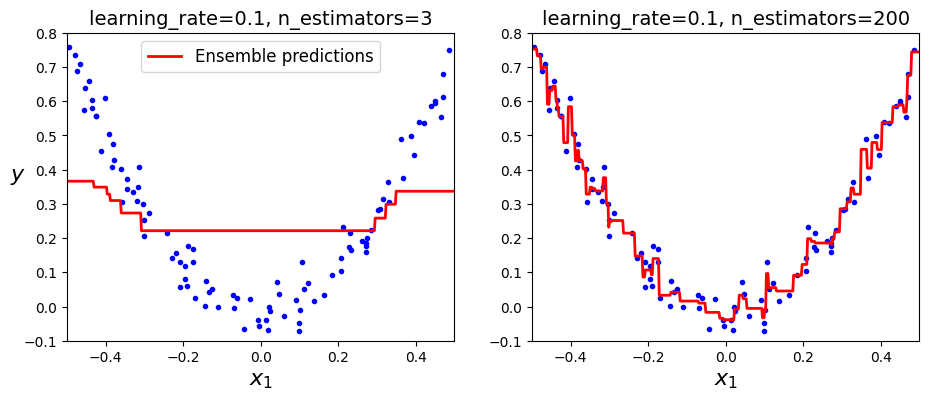

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor

# 1. 生成带有噪声的二次曲线数据集
np.random.seed(42)
X = np.random.rand(100, 1) - 0.5
y = 3*X[:, 0]**2 + 0.05 * np.random.randn(100)

# 2. 训练两个不同规模的 GBRT 模型
# 左图模型：预测器太少 (n_estimators=3)
gbrt_slow = GradientBoostingRegressor(max_depth=2, n_estimators=3, learning_rate=0.1, random_state=42)
gbrt_slow.fit(X, y)

# 右图模型：预测器太多 (n_estimators=200)
gbrt_fast = GradientBoostingRegressor(max_depth=2, n_estimators=200, learning_rate=0.1, random_state=42)
gbrt_fast.fit(X, y)

# 3. 绘图辅助函数
def plot_predictions(regressors, X, y, axes, label=None, style="r-", data_style="b.", data_label=None):
    x1 = np.linspace(axes[0], axes[1], 500).reshape(-1, 1)
    # 对于单个模型，regressors 列表里只有一个元素
    y_pred = sum(regressor.predict(x1) for regressor in regressors)
    plt.plot(X[:, 0], y, data_style, label=data_label)
    plt.plot(x1[:, 0], y_pred, style, linewidth=2, label=label)
    if label or data_label:
        plt.legend(loc="upper center", fontsize=12)
    plt.axis(axes)

# 4. 绘制对比图
plt.figure(figsize=(11, 4))

# 左侧子图：n_estimators=3
plt.subplot(121)
plot_predictions([gbrt_slow], X, y, axes=[-0.5, 0.5, -0.1, 0.8], label="Ensemble predictions")
plt.title("learning_rate=0.1, n_estimators=3", fontsize=14)
plt.xlabel("$x_1$", fontsize=16)
plt.ylabel("$y$", fontsize=16, rotation=0)

# 右侧子图：n_estimators=200
plt.subplot(122)
plot_predictions([gbrt_fast], X, y, axes=[-0.5, 0.5, -0.1, 0.8])
plt.title("learning_rate=0.1, n_estimators=200", fontsize=14)
plt.xlabel("$x_1$", fontsize=16)

plt.show()


直观地展示了 **欠拟合**（树太少，无法捕捉数据趋势）与 **过拟合**（树太多，开始拟合噪声）之间的区别。

---

### 图像关键现象分析

1. **左图 (n_estimators=3)**：
* **现象**：红色预测线非常简单，呈大阶梯状，没能很好地经过蓝色的数据点集。
* **结论**：这是典型的 **欠拟合 (Underfitting)**，因为预测器数量不足以学习到数据中的二次曲线规律。


2. **右图 (n_estimators=200)**：
* **现象**：预测线变得非常“抖动”，甚至去尝试穿过每一个离群的噪声点。
* **结论**：这是典型的 **过拟合 (Overfitting)**。模型学习得太细，以至于把训练集里的随机噪声也当成了规律，这会导致它在处理新数据时表现很差。

---


手动尝试 `n_estimators` 就像是在“碰运气”。

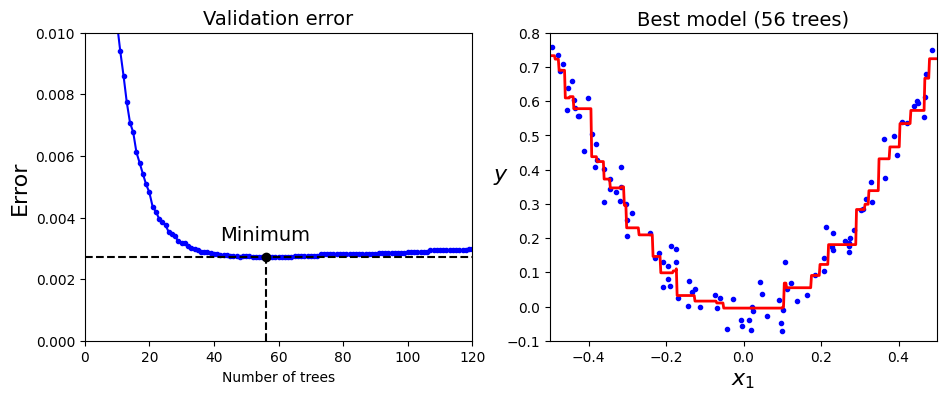

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import GradientBoostingRegressor

# 1. 数据准备
np.random.seed(42)
X = np.random.rand(100, 1) - 0.5
y = 3*X[:, 0]**2 + 0.05 * np.random.randn(100)
X_train, X_val, y_train, y_val = train_test_split(X, y, random_state=49)

# 2. 训练一个拥有足够多树的模型
gbrt = GradientBoostingRegressor(max_depth=2, n_estimators=120, learning_rate=0.1, random_state=42)
gbrt.fit(X_train, y_train)

# 3. 计算每个阶段的验证误差
errors = [mean_squared_error(y_val, y_pred) for y_pred in gbrt.staged_predict(X_val)]
bst_n_estimators = np.argmin(errors) + 1 # 找到误差最小的索引
min_error = np.min(errors)

# 4. 使用最优数量训练模型
gbrt_best = GradientBoostingRegressor(max_depth=2, n_estimators=bst_n_estimators, learning_rate=0.1, random_state=42)
gbrt_best.fit(X_train, y_train)

# 5. 绘图
plt.figure(figsize=(11, 4))

# 左图：验证误差曲线
plt.subplot(121)
plt.plot(np.arange(1, 121), errors, "b.-")
plt.plot([bst_n_estimators, bst_n_estimators], [0, min_error], "k--") # 垂直虚线
plt.plot([0, 120], [min_error, min_error], "k--") # 水平虚线
plt.plot(bst_n_estimators, min_error, "ko") # 最小误差圆点
plt.text(bst_n_estimators, min_error*1.2, "Minimum", ha="center", fontsize=14)
plt.axis([0, 120, 0, 0.01])
plt.xlabel("Number of trees")
plt.ylabel("Error", fontsize=16)
plt.title("Validation error", fontsize=14)

# 右图：最佳模型拟合效果
plt.subplot(122)
def plot_predictions(regressor, X, y, axes):
    x1 = np.linspace(axes[0], axes[1], 500).reshape(-1, 1)
    y_pred = regressor.predict(x1)
    plt.plot(X[:, 0], y, "b.")
    plt.plot(x1[:, 0], y_pred, "r-", linewidth=2)
    plt.axis(axes)

plot_predictions(gbrt_best, X, y, axes=[-0.5, 0.5, -0.1, 0.8])
plt.title(f"Best model ({bst_n_estimators} trees)", fontsize=14)
plt.xlabel("$x_1$", fontsize=16)
plt.ylabel("$y$", fontsize=16, rotation=0)

plt.show()

展示验证误差随树数量变化的曲线，并标记出那个误差最小的“黄金分割点”，同时配合展示该最优数量下的模型拟合效果。

---

### 图像核心解析

* **左图（验证误差）**：看到误差随着树的数量增加先快速下降，但在达到某个点（大约 55 棵树）后开始缓慢回升。这个误差开始回升的转折点，就是模型开始**过拟合**训练集噪声的时刻。
* **右图（最优模型）**：使用找到的 `bst_n_estimators` 进行预测，发现红色的曲线既捕捉到了二次方的趋势，又没有像 200 棵树时那样产生剧烈的抖动，达到了理想的泛化状态。


# 堆叠法

**堆叠法（Stacking，也称为叠加泛化）**

它的核心思想非常简洁且符合直觉：既然我们可以通过“投票”或“加权”来组合预测器的结果，为什么不干脆**训练一个模型来学习如何组合这些结果**呢？

---

### 1. 核心架构：多层预测

堆叠法通常由两个层级的预测器组成：

* **第一层（Base-learners）**：包含多个不同的预测器（如一个随机森林、一个 SVM 和一个分类器）。它们各自对原始测试集进行预测，并输出结果。
* **第二层（Blender / Meta-learner）**：这是一个最终的预测器，它的**训练输入**是第一层预测器的所有输出结果，**训练目标**是原始的真实标签。

---

### 2. 训练流程：如何避免“作弊”？

为了训练元学习器（Blender），我们需要确保它的输入数据是它从未见过的“新信息”。书中介绍了一种基于**留出集（Hold-out set）**的经典训练方案：

1. **拆分数据集**：将原始训练集分成两个子集（子集 A 和子集 B）。
2. **训练第一层**：在子集 A 上训练所有的第一层预测器。
3. **生成元特征**：使用训练好的第一层预测器去预测子集 B。由于子集 B 对这些模型来说是全新的，其预测结果可以看作是模型在实际应用中的表现。
4. **训练元学习器**：将子集 B 的预测结果作为输入特征，子集 B 的真实标签作为目标，来训练元学习器。

---

### 3. 多层堆叠

理论上，可以构建更复杂的堆叠结构，比如三层甚至四层：

* 第一层输出传给第二层的三个模型。
* 第二层输出再传给第三层的一个最终模型。
* **代价**：这通常能提升一点点精度，但会极大地增加系统的复杂性和过拟合风险。


---

### 本章大总结

到这里，我们就完成了《集成学习与随机森林》整章的内容整理。我们回顾一下：

* **投票集成**：靠群众的力量。
* **Bagging & Pasting**：靠并行和采样（如随机森林）。
* **Boosting**：靠串行和纠错（如 AdaBoost、梯度提升、XGBoost）。
* **Stacking**：靠模型来学习如何组合模型。
